## Importation des packages et données

In [28]:
using Pkg

cd(@__DIR__)
Pkg.activate("../")
using Dates, SonifSismo
using WAV
using DSP
using Statistics
using Interpolations

Pkg.update("CairoMakie")   # mettre à jour
using CairoMakie

archive = DataArchive("C:/Users/ameli/Desktop/Stage/mtFujiContinuous")

  Activating project at `c:\Users\ameli\Desktop\Stage\sonifSismo.jl`
    Updating registry at `C:\Users\ameli\.julia\registries\General.toml`
┌ Error: Some registries failed to update:
│     — C:\Users\ameli\.julia\registries\General.toml — failed to download from https://pkg.julialang.org/registry/23338594-aafe-5451-b93e-139f81909106/d5792237e68d7f3cd2fa3dddd17875f5980888e7. Exception: RequestError: HTTP/1.1 302 Moved Temporarily (Could not resolve host: storage.julialang.net) while requesting https://pkg.julialang.org/registry/23338594-aafe-5451-b93e-139f81909106/d5792237e68d7f3cd2fa3dddd17875f5980888e7
└ @ Pkg.Registry C:\Users\ameli\.julia\juliaup\julia-1.12.6+0.x64.w64.mingw32\share\julia\stdlib\v1.12\Pkg\src\Registry\Registry.jl:574
     Project No packages added to or removed from `C:\Users\ameli\Desktop\Stage\sonifSismo.jl\Project.toml`
    Manifest No packages added to or removed from `C:\Users\ameli\Desktop\Stage\sonifSismo.jl\Manifest.toml`


DataArchive("C:\\Users\\ameli\\Desktop\\Stage\\mtFujiContinuous", "C:\\Users\\ameli\\Desktop\\Stage\\mtFujiContinuous\\mseed", "C:\\Users\\ameli\\Desktop\\Stage\\mtFujiContinuous\\catalog\\h2008", :JST, Hour(9))

In [29]:
dossier = "C:\\Users\\ameli\\Desktop\\Stage\\Résultats\\26Juin\\test\\deux"


"C:\\Users\\ameli\\Desktop\\Stage\\Résultats\\26Juin\\test\\deux"

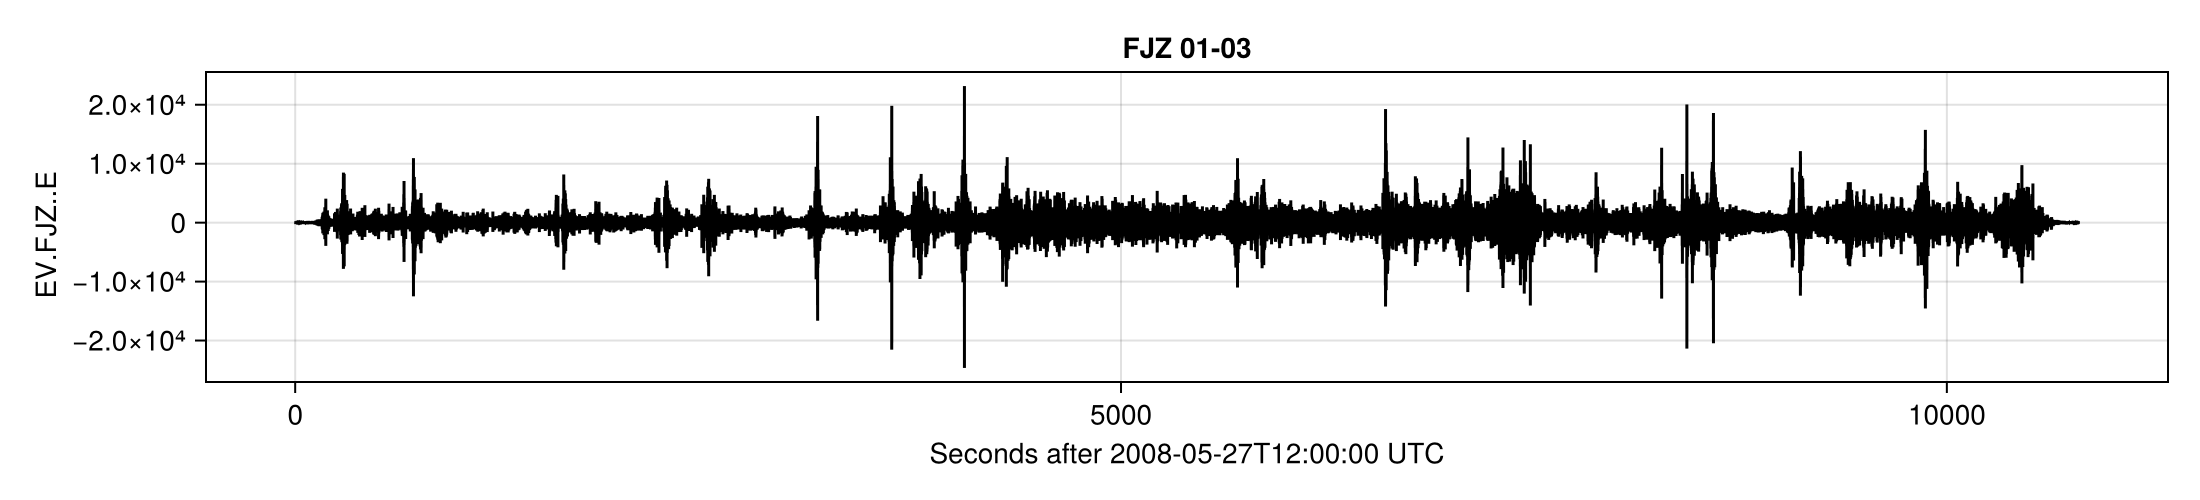

In [30]:
t0_utc = DateTime(2008, 5, 27, 21, 0, 0) - Hour(9)
t1_utc = DateTime(2008, 5, 27, 23, 59, 59) - Hour(9)


events = read_catalog(archive; start=t0_utc, stop=t1_utc)


traces = read_window(
    archive,  t0_utc, t1_utc;
    stations  = "FJZ",
    channels  = ["E"],
    processed = true,
    bandpass  = (1, 15.0),
)

include("C:/Users/ameli/Desktop/Stage/sonifSismo.jl/examples/sonify_one_trace.jl")

trace = only(t for t in traces if strip(t.sta.cha) == "E")



wavefig = plot_waveforms(
    traces;
    title  = "FJZ 01-03",
)


const AUDIO_OUTPUT = joinpath(dossier)
mkpath(dossier)

save(joinpath(AUDIO_OUTPUT, "00_sis.png"), wavefig)

wavefig


## Simple Sonification

In [31]:
final_sound = sonify_trace(
    trace;
    acceleration=120,
    #octave=4,
    #harmonics=(0.3, 0.2),
    #gain=2,
    #saturation=:soft,
    level=1
)

if maximum(abs.(final_sound[1])) > 1
    final_sound[1] = final_sound[1] ./ maximum(abs.(final_sound[1]))
end

const AUDIO_OUTPUT = joinpath(dossier)
mkpath(dossier)

wavwrite(Float32.(final_sound[1]), joinpath(AUDIO_OUTPUT,"01_sonifytrace.wav"); Fs=44100)

## Convolution avec musique

In [32]:
final_sound = sonify_trace(
    trace;
    acceleration=120,
    #octave=4,
    #harmonics=(0.3, 0.2),
    #gain=2,
    saturation=:soft,
    level=0.2
)

musique, sr_musique = wavread("C:\\Users\\ameli\\Desktop\\Stage\\Gamme Chromatique.wav") #Mettre le lien de sa musique

signal = musique[20000:110000]

convolution = conv(final_sound[1], signal)
convolution2 = conv(trace.t, signal)


if maximum(abs.(convolution)) > 1
    convolution = convolution ./ maximum(abs.(convolution))
end

if maximum(abs.(convolution2)) > 1
    convolution2 = convolution2 ./ maximum(abs.(convolution2))
end

const AUDIO_OUTPUT = joinpath(dossier)
mkpath(dossier)

wavwrite(Float32.(convolution), joinpath(AUDIO_OUTPUT,"02_convolution_sonifytrace.wav"); Fs=sr_musique)
wavwrite(Float32.(convolution), joinpath(AUDIO_OUTPUT,"03_convolution_sans_sonifytrace.wav"); Fs=sr_musique)

In [33]:
signal = musique[20000:110000]

wavplay(signal, sr_musique)

## Interpolation

In [34]:

function sinc_interp(x, t_old, t_new)

    dt = t_old[2]-t_old[1]

    y = zeros(length(t_new))

    for i in eachindex(t_new)
        for j in eachindex(x)

            u = (t_new[i]-t_old[j])/dt

            y[i] += x[j]*sinc(u)

        end
    end

    y

end


sinc_interp (generic function with 1 method)

In [35]:
#= f = trace_wE.t
t = range(0, step=1/50, length=length(f))

t2 = range(first(t), last(t), length=4*length(t))


f_lin = linear_interpolation(t, f).(t2)

f_cub = cubic_spline_interpolation(t, f).(t2)

f_sinc = sinc_interp(f, t, t2)

fig = Figure(size=(1100,220))
ax = Axis(fig[1,1])

lines!(t, f, label="Original")
lines!(t2, f_lin, label="Linéaire")
lines!(t2, f_cub, label="Cubique")
lines!(t2, f_sinc, label="Sinc")

axislegend(ax)

fig

=#

In [36]:
#= 

fig = Figure(size=(1200,700))

ax1 = Axis(fig[1,1],
    title="Interpolation linéaire")

ax2 = Axis(fig[2,1],
    title="Interpolation cubique")

ax3 = Axis(fig[3,1],
    title="Interpolation sinc")


# Linéaire
lines!(ax1, t, f)
lines!(ax1, t2, f_lin)


# Cubique
lines!(ax2, t, f)
lines!(ax2, t2, f_cub)


# Sinc
lines!(ax3, t, f)
lines!(ax3, t2, f_sinc)


# Même fenêtre de visualisation
linkxaxes!(ax1, ax2, ax3)

# Zoom optionnel pour voir les différences
# xlims!(ax1, 2.0, 2.5)


fig

=#

## Sonification

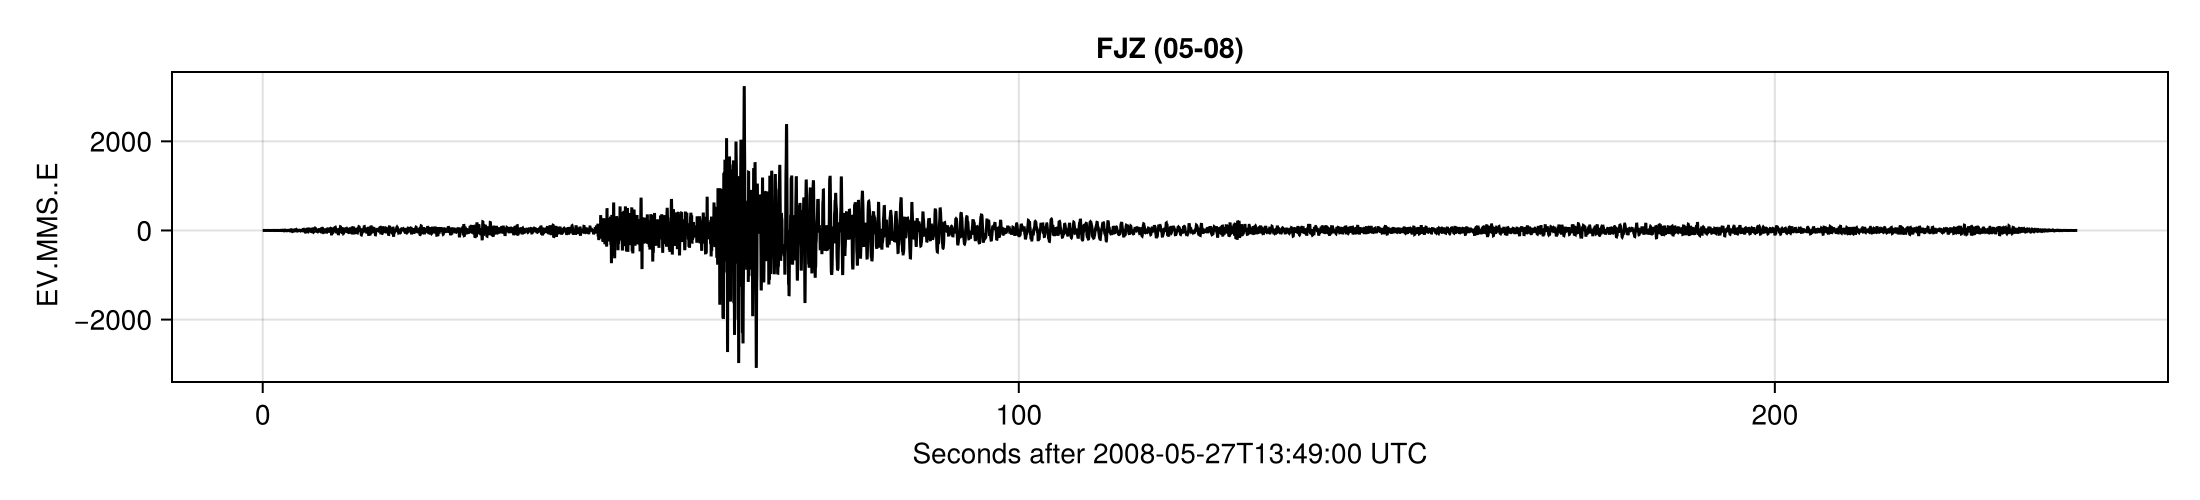

In [37]:
t0_utc = DateTime(2008, 5, 27, 22, 49, 0) - Hour(9)
t1_utc = DateTime(2008, 5, 27, 22, 53, 0) - Hour(9)

events = read_catalog(archive; start=t0_utc, stop=t1_utc)


traces = read_window(
    archive,  t0_utc, t1_utc;
    stations  = "MMS",
    channels  = ["E"],
    processed = true,
    bandpass  = (1, 15.0),
)

include("C:/Users/ameli/Desktop/Stage/sonifSismo.jl/examples/sonify_one_trace.jl")

trace = only(t for t in traces if strip(t.sta.cha) == "E")



wavefig = plot_waveforms(
    traces;
    title  = "FJZ (05-08)",
)


const AUDIO_OUTPUT = joinpath(dossier)
mkpath(dossier)

save(joinpath(AUDIO_OUTPUT, "04_sis.png"), wavefig)

wavefig


In [38]:

const AUDIO_OUTPUT = joinpath(dossier)
mkpath(dossier)

"C:\\Users\\ameli\\Desktop\\Stage\\Résultats\\26Juin\\test\\deux"

In [39]:
f = trace.t
fs_sismo = 100

t  = range(0, step=1/fs_sismo, length=length(f))
t2 = range(0, stop=last(t), step=1/44100)

audio44 = cubic_spline_interpolation(t, f).(t2)
audio44 ./= maximum(abs.(audio44))

mkpath(dossier)
wavwrite(audio44, joinpath(dossier, "05_interpolation.wav"); Fs=44100)

In [40]:

musique, sr_musique = wavread("C:\\Users\\ameli\\Desktop\\Stage\\Gamme Chromatique.wav") #Mettre le lien de sa musique

signal = musique[20000:110000]

convolution = conv(signal, audio44)

if maximum(abs.(convolution)) > 1
    convolution = convolution ./ maximum(abs.(convolution))
end

const AUDIO_OUTPUT = joinpath(dossier)
mkpath(dossier)

wavwrite(convolution, joinpath(AUDIO_OUTPUT,"06_convolution_et_interpolation.wav"); Fs=44100)


## Phase Vocoder : changement octave

In [41]:
function pitch_shift_fft(x::Vector{Float64}, semitones::Real)
    r = 2.0^(semitones / 12)
    N = length(x)
    X = fft(x)
    X_shift = zeros(ComplexF64, N)

    for k in 2:N÷2-1          
        k_new = round(Int, (k - 1) * r) + 1
        2 <= k_new <= N÷2-1 || continue
        X_shift[k_new]         += X[k]
        X_shift[N - k_new + 2] += conj(X[k])
    end

    x_out = real(ifft(X_shift))
    m = maximum(abs.(x_out))
    m < 1e-10 && return zeros(N)   
    x_out ./= m
    return x_out
end

signal_octave = pitch_shift_fft(audio44, 26)   # +1 octave, même durée

convolution_octave = conv(signal_octave, signal)

if maximum(abs.(signal_octave)) > 1
    signal_octave = signal_octave ./ maximum(abs.(signal_octave))
end

if maximum(abs.(convolution_octave)) > 1
    convolution_octave = convolution_octave ./ maximum(abs.(convolution_octave))
end

wavwrite(Float32.(signal_octave), joinpath(AUDIO_OUTPUT,"07_octave_changement.wav"); Fs=44100)
wavwrite(Float32.(convolution_octave), joinpath(AUDIO_OUTPUT,"08_octave_convolution.wav"); Fs=44100)



## Plot figure

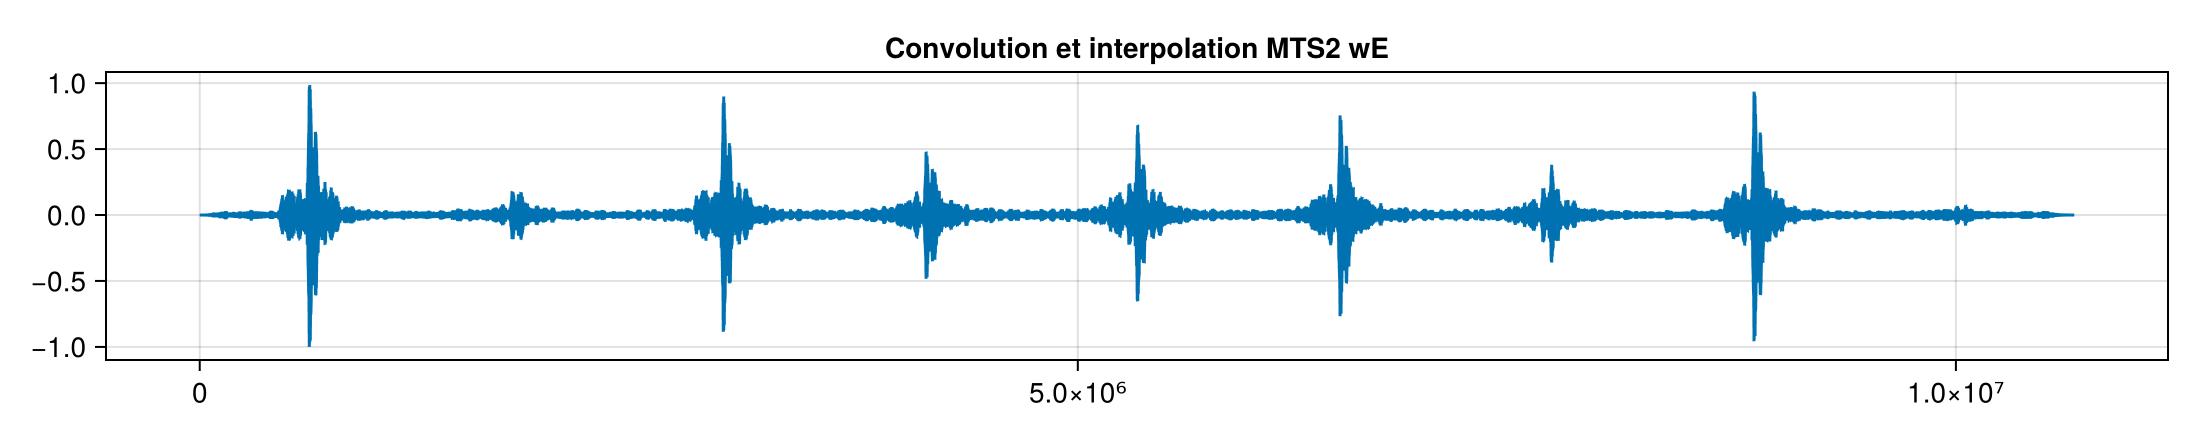

In [42]:

fig = Figure(size=(1100, 220))
ax = Axis(fig[1,1], title="Convolution et interpolation MTS2 wE")
lines!(ax, convolution_octave)
fig

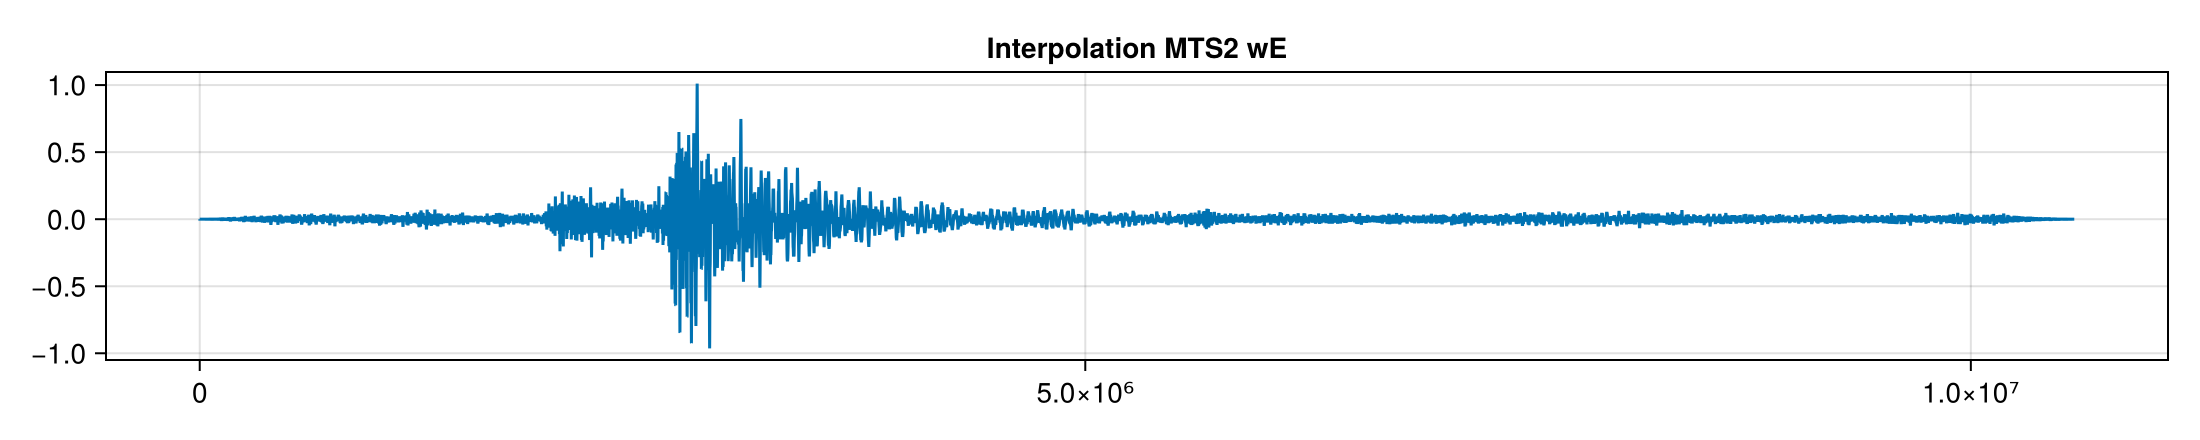

In [43]:
fig = Figure(size=(1100, 220))
ax = Axis(fig[1,1], title="Interpolation MTS2 wE")
lines!(ax, audio44)
fig

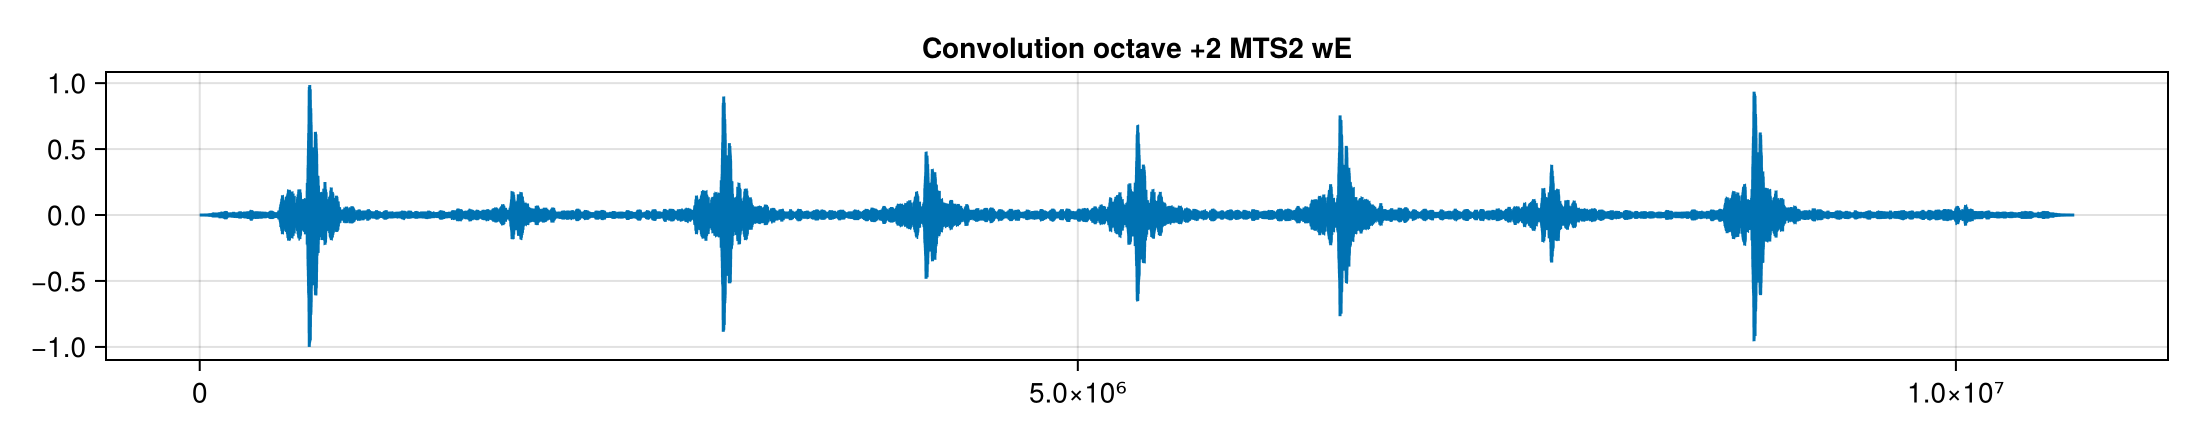

In [44]:
fig = Figure(size=(1100, 220))
ax = Axis(fig[1,1], title="Convolution octave +2 MTS2 wE")
lines!(ax, convolution_octave)
fig

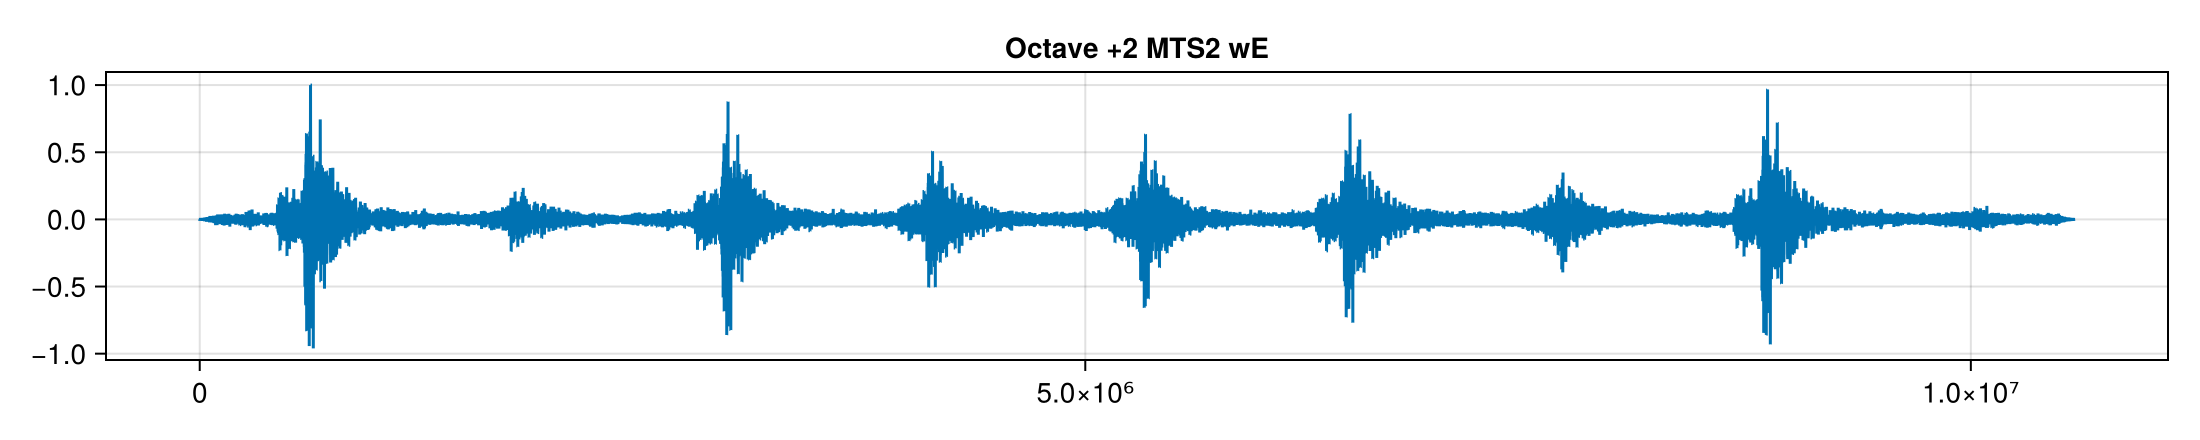

In [45]:
fig = Figure(size=(1100, 220))
ax = Axis(fig[1,1], title="Octave +2 MTS2 wE")
lines!(ax, signal_octave)
fig